# Clustering: segmentacion de clientes

## Objetivo

Esta libreta construye una segmentacion de clientes con **K-Means**.

Como clustering es aprendizaje no supervisado, no hay una variable objetivo. El modelo agrupa clientes por comportamiento:

- frecuencia de visitas
- recencia
- gasto total
- tasa historica de no-show

Tambien se incluyen dos tecnicas para justificar el numero de grupos:

- **Metodo del codo**: compara la inercia para varios valores de K.
- **Dendrograma**: visualiza similitud jerarquica entre clientes.

In [1]:
from pathlib import Path
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

sns.set_theme(style="whitegrid")

SERVER_ROOT = Path.cwd()
if SERVER_ROOT.name == "notebooks":
    SERVER_ROOT = SERVER_ROOT.parents[1]
elif SERVER_ROOT.name == "ml":
    SERVER_ROOT = SERVER_ROOT.parent

ARTIFACT_DIR = SERVER_ROOT / "ml" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def load_env(path):
    env = {}
    for raw in Path(path).read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        env[key.strip()] = value.strip().strip('"').strip("'")
    return env

env = {**load_env(SERVER_ROOT / ".env"), **os.environ}

def connect():
    conn = psycopg2.connect(
        host=env.get("DB_HOST", "localhost"),
        port=int(env.get("DB_PORT", 5432)),
        user=env.get("DB_USER", "postgres"),
        password=env.get("DB_PASSWORD", ""),
        dbname=env.get("DB_NAME", "db_barberia"),
    )
    with conn.cursor() as cur:
        cur.execute("SET search_path TO core, catalogo, admin, public")
    return conn

conn = connect()
df = pd.read_sql_query("SELECT * FROM analitica.ml_citas_dataset ORDER BY id", conn)
df["fecha"] = pd.to_datetime(df["fecha"])
df["hora"] = pd.to_datetime(df["hora"].astype(str), format="%H:%M:%S", errors="coerce").dt.hour
df.head()

C:\Users\Javi\AppData\Local\Temp\ipykernel_3928\267030489.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM analitica.ml_citas_dataset ORDER BY id", conn)


,id,cliente_ref,cliente_nombre,local_id,local_nombre,servicio_id,servicio_nombre,barbero_id,barbero_nombre,fecha,...,monto_pagado,estado_cita,recordatorio_enviado,frecuencia_cliente,recencia_dias,gasto_total_cliente,no_show_rate_cliente,canal,seed_run_id,created_at
0,1,20,Eduardo Reyes,1,Barbería Carlyn,12,Paquete 2 - Ritual Caballero,35,Luis Hernández,2026-05-22,...,319.15,asistio,True,3,12,889.09,0.0794,walk-in,20260722084715,2026-07-22 08:47:15.164613
1,2,204,Emiliano Cruz,1,Barbería Carlyn,11,Paquete 1 - Corte First Class,34,Carlos Méndez,2026-06-16,...,246.26,asistio,False,4,58,584.85,0.0876,telefono,20260722084715,2026-07-22 08:47:15.164613
2,3,159,Pablo Lopez,1,Barbería Carlyn,12,Paquete 2 - Ritual Caballero,34,Carlos Méndez,2026-07-16,...,313.55,asistio,True,8,23,1075.99,0.0815,web,20260722084715,2026-07-22 08:47:15.164613
3,4,106,Sergio Aguilar,1,Barbería Carlyn,12,Paquete 2 - Ritual Caballero,34,Carlos Méndez,2026-07-13,...,315.20,asistio,False,2,66,660.94,0.2215,web,20260722084715,2026-07-22 08:47:15.164613
4,5,118,Miguel Moreno,1,Barbería Carlyn,13,Paquete 3 - Premium Black,34,Carlos Méndez,2026-02-19,...,376.15,asistio,True,3,58,429.97,0.3574,walk-in,20260722084715,2026-07-22 08:47:15.164613


## 1. Dataset a nivel cliente

Agregamos las citas para tener una fila por cliente.

In [2]:
clients = (
    df.groupby(["cliente_ref", "cliente_nombre"], as_index=False)
    .agg(
        frecuencia_90d=("frecuencia_cliente", "max"),
        recencia_dias=("recencia_dias", "min"),
        gasto_total=("gasto_total_cliente", "max"),
        no_show_rate=("no_show_rate_cliente", "max"),
        citas=("id", "count"),
    )
)

clients.head()

,cliente_ref,cliente_nombre,frecuencia_90d,recencia_dias,gasto_total,no_show_rate,citas
0,1,Jose Ruiz,6,110,1068.79,0.0901,2
1,2,Javier Reyes,5,36,508.96,0.0757,2
2,3,Hector Vega,3,32,647.85,0.2258,3
3,4,Ivan Moreno,5,54,1122.87,0.1151,4
4,5,Pablo Ruiz,4,67,1125.75,0.1681,4


## 2. Escalamiento de variables

K-Means usa distancias. Si no escalamos, `gasto_total` dominaria al resto solo por tener numeros mas grandes.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

features = ["frecuencia_90d", "recencia_dias", "gasto_total", "no_show_rate"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clients[features])

## 3. Metodo del codo

Entrenamos K-Means con varios valores de K. Buscamos el punto donde agregar mas clusters ya no reduce tanto la inercia.

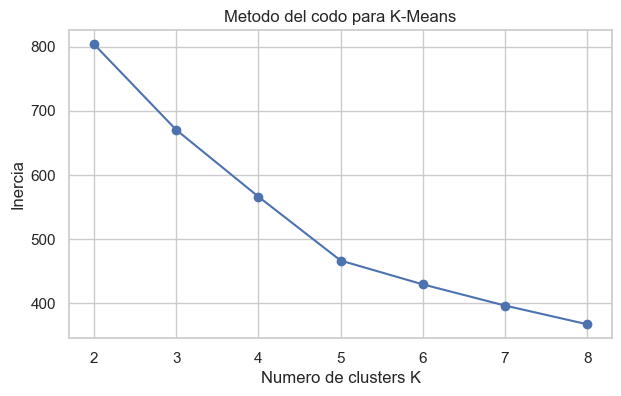

,k,inercia
0,2,803.512293
1,3,670.176344
2,4,566.120518
3,5,466.647615
4,6,429.518401
5,7,396.524776
6,8,367.436826


In [4]:
ks = range(2, 9)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=12)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("Numero de clusters K")
plt.ylabel("Inercia")
plt.title("Metodo del codo para K-Means")
plt.show()

pd.DataFrame({"k": list(ks), "inercia": inertias})

## 4. Dendrograma

El dendrograma no entrena K-Means, pero ayuda a entender que tan separados estan los grupos. Para que sea legible, se toma una muestra de clientes.

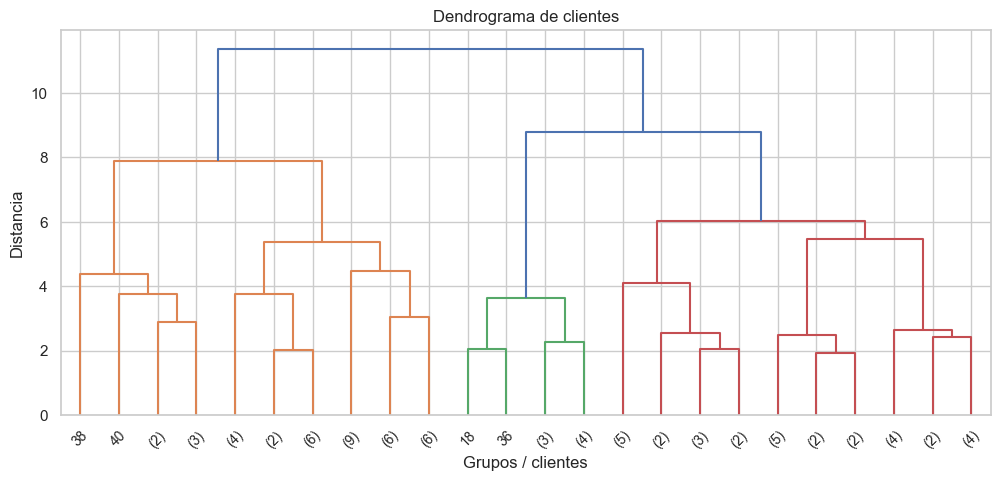

In [5]:
sample_size = min(80, len(clients))
sample_idx = np.random.RandomState(42).choice(len(clients), size=sample_size, replace=False)
linked = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=24)
plt.title("Dendrograma de clientes")
plt.xlabel("Grupos / clientes")
plt.ylabel("Distancia")
plt.show()

## 5. Entrenamiento final con K=4

Con base en la propuesta de negocio y el analisis visual, usamos 4 segmentos:

- VIP frecuentes
- Ocasionales
- Riesgo de fuga
- Nuevos/prueba

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=12)
clients["cluster"] = kmeans.fit_predict(X_scaled)

cluster_stats = clients.groupby("cluster")[features].mean()
cluster_stats

,frecuencia_90d,recencia_dias,gasto_total,no_show_rate
cluster,,,,
0,4.866667,114.666667,772.246667,0.132030
1,4.123457,47.506173,1151.158395,0.137090
2,3.421875,46.671875,635.790625,0.282402
3,7.000000,38.704225,699.479718,0.134146


## 6. Etiquetado de segmentos

K-Means solo entrega numeros de cluster. Nosotros asignamos nombres de negocio interpretando los promedios.

In [7]:
labels = {}
used = set()

vip = cluster_stats.sort_values(["gasto_total", "frecuencia_90d"], ascending=False).index[0]
labels[vip] = "VIP frecuentes"
used.add(vip)

risk = cluster_stats.drop(index=list(used)).sort_values(["recencia_dias", "no_show_rate"], ascending=False).index[0]
labels[risk] = "Riesgo de fuga"
used.add(risk)

new = cluster_stats.drop(index=list(used)).sort_values("frecuencia_90d", ascending=True).index[0]
labels[new] = "Nuevos/prueba"
used.add(new)

for cluster in cluster_stats.index:
    if cluster not in labels:
        labels[cluster] = "Ocasionales"

clients["segmento"] = clients["cluster"].map(labels)
clients["segmento"].value_counts()

segmento
VIP frecuentes    81
Ocasionales       71
Nuevos/prueba     64
Riesgo de fuga    30
Name: count, dtype: int64

## 7. Visualizacion de segmentos

Graficamos gasto contra recencia para ver como se distribuyen los grupos.

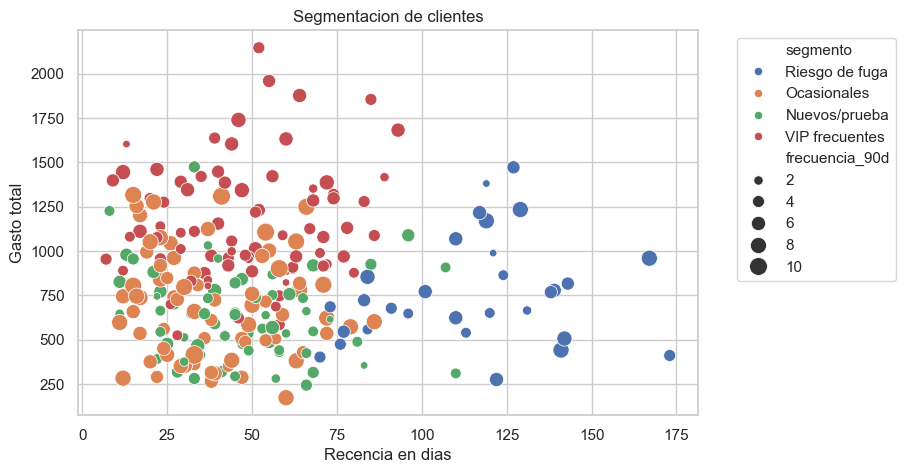

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=clients,
    x="recencia_dias",
    y="gasto_total",
    hue="segmento",
    size="frecuencia_90d",
    sizes=(30, 180),
)
plt.title("Segmentacion de clientes")
plt.xlabel("Recencia en dias")
plt.ylabel("Gasto total")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 8. Acciones por segmento

Traducimos cada grupo a una decision comercial.

In [9]:
actions = {
    "VIP frecuentes": "Beneficio premium y acceso anticipado",
    "Ocasionales": "Recordatorio de proxima visita",
    "Riesgo de fuga": "Promocion de regreso con vigencia corta",
    "Nuevos/prueba": "Seguimiento post-servicio",
}

clients["accion_sugerida"] = clients["segmento"].map(actions)
clients.sort_values(["segmento", "gasto_total"], ascending=[True, False]).head(20)

,cliente_ref,cliente_nombre,frecuencia_90d,recencia_dias,gasto_total,no_show_rate,citas,cluster,segmento,accion_sugerida
76,77,Raul Ruiz,4,33,1474.38,0.4666,6,2,Nuevos/prueba,Seguimiento post-servicio
101,104,Miguel Lopez,3,8,1225.84,0.3636,2,2,Nuevos/prueba,Seguimiento post-servicio
182,187,Daniel Reyes,5,96,1088.74,0.4457,4,2,Nuevos/prueba,Seguimiento post-servicio
196,201,Daniel Santos,2,37,1031.49,0.5983,8,2,Nuevos/prueba,Seguimiento post-servicio
109,112,Daniel Vega,5,13,979.08,0.4389,7,2,Nuevos/prueba,Seguimiento post-servicio
30,31,Carlos Aguilar,2,40,957.46,0.3113,1,2,Nuevos/prueba,Seguimiento post-servicio
213,218,Hector Moreno,4,15,955.26,0.3394,5,2,Nuevos/prueba,Seguimiento post-servicio
22,23,Oscar Martinez,4,85,925.17,0.6422,3,2,Nuevos/prueba,Seguimiento post-servicio
70,71,Brayan Torres,5,68,919.19,0.2629,4,2,Nuevos/prueba,Seguimiento post-servicio
52,53,Alexis Garcia,3,107,907.63,0.3741,4,2,Nuevos/prueba,Seguimiento post-servicio


## 9. Guardado del modelo

Guardamos el escalador, el modelo K-Means y las etiquetas de negocio.

In [10]:
artifact_path = ARTIFACT_DIR / "notebook_client_kmeans_segmentation.joblib"
joblib.dump({"scaler": scaler, "model": kmeans, "labels": labels}, artifact_path)
artifact_path

WindowsPath('C:/Users/Javi/Desktop/Frameworks/React/Barberia Carlyn/barberia-carlyn-server/ml/artifacts/notebook_client_kmeans_segmentation.joblib')